### Deutsch's problem

Input: a function $f:\{0,1\} \to {0,1}$

Output: 0 if $f$ is constant, 1 if $f$ is balanced

$f_0(0)=0, \; f_0(1)=0$

$f_1(0)=0, \; f_1(1)=1$

$f_2(0)=1, \; f_2(1)=0$

$f_3(0)=1, \; f_3(1)=1$

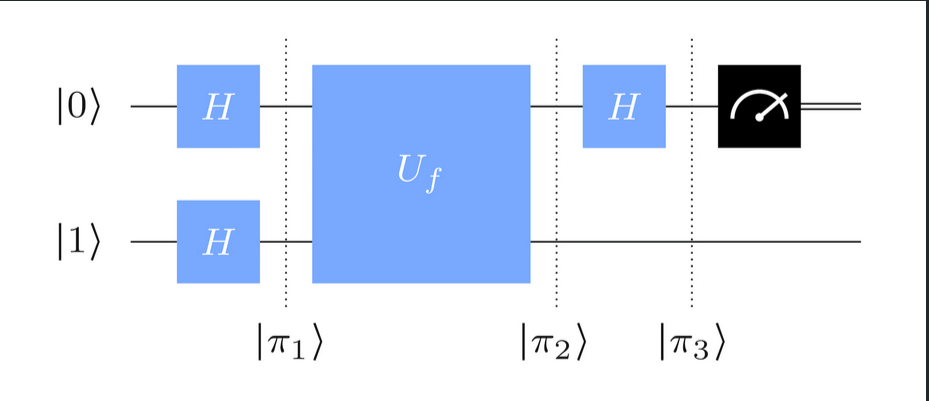

$U_f \ket{x} \ket{y} = \ket{x} \ket{y \oplus f(x)}$

$\ket{\pi_1} = \ket{+} \ket{-}$

$\ket{\pi_2} =  (-1)^{f(0)}\left( \frac{\ket{0} + (-1)^{f(0) \oplus f(1)}\ket{1}}{\sqrt{2}} \right) \ket{-}$

$\ket{\pi_3} = H\ket{+} = \ket{0}$ if $f(0) \oplus f(1) = 0$

$\ket{\pi_3} = H\ket{-} = \ket{1}$ if $f(0) \oplus f(1) = 1$

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [2]:
def oracle(case: int) -> QuantumCircuit:
    if case not in range(4):
        raise ValueError("Case must be one of [0, 1, 2, 3]")
    qc = QuantumCircuit(2)
    if case == 1 or case == 2:
        qc.cx(0, 1)
    if case == 2 or case == 3:
        qc.x(1)
    return qc

In [3]:
def build_circuit(case: int) -> QuantumCircuit:
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.barrier()
    qc.compose(oracle(case), inplace=True)
    qc.barrier()
    qc.h(0)
    qc.measure(0, 0)
    return qc


In [4]:
qc = build_circuit(2)

In [5]:
qc.draw()

┌───┐      ░            ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───■────────░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌───┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘└───┘ ░       ║ 
c: 1/════════════════════════════════╩═
                                     0

In [17]:
qc = build_circuit(2)
result = AerSimulator().run(qc, shots=1024).result()
counts = result.get_counts()

In [18]:
counts

{'1': 1024}

In [19]:
%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [20]:
import os
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram

In [21]:
token = os.environ["IBMQ_TOKEN"]

In [22]:
service = QiskitRuntimeService(
                token=token,
                channel="ibm_quantum",
            )
backend = service.least_busy(operational=True, simulator=False)

/tmp/ipykernel_27357/1493915476.py:1: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService(


In [23]:
transpiled = transpile(qc, backend=backend)

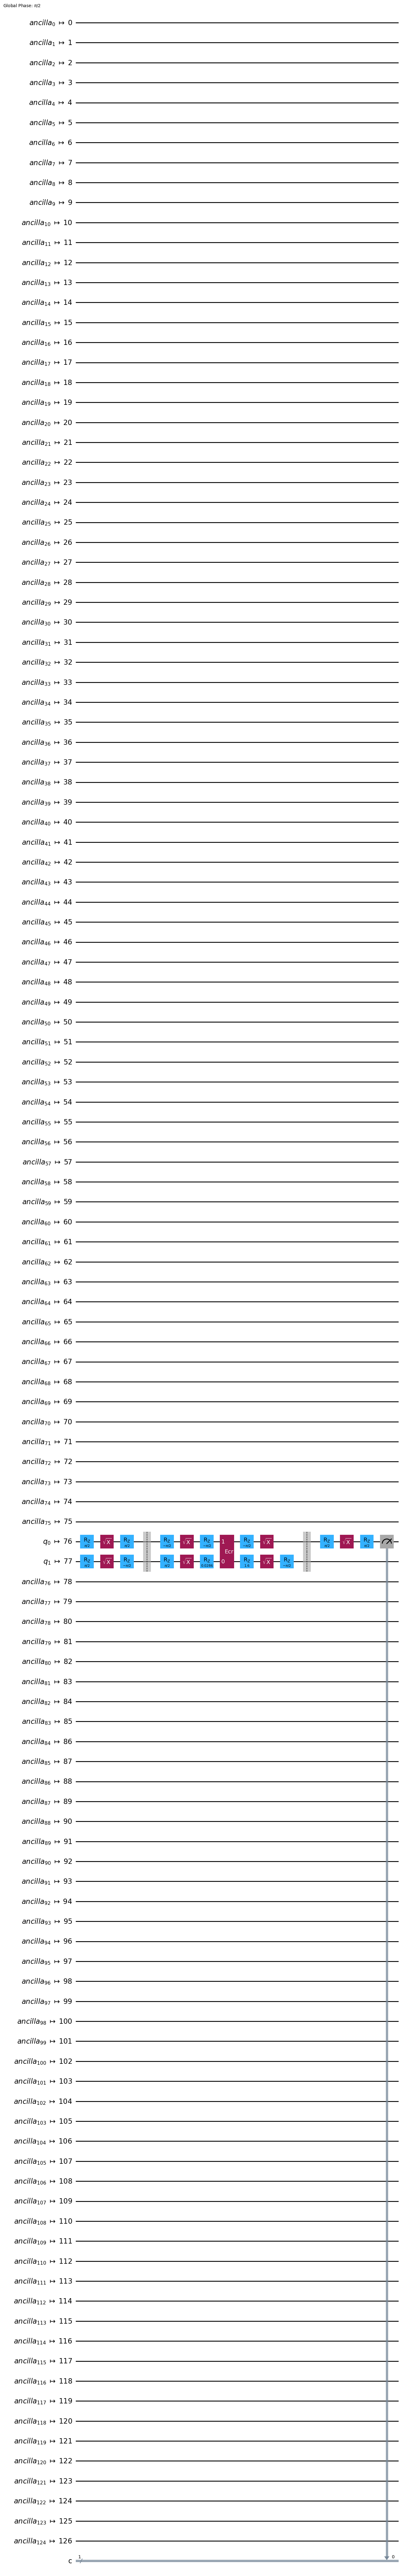

In [24]:
transpiled.draw(output="mpl")

In [ ]:
sampler = SamplerV2(backend)
job = sampler.run([transpiled], shots=8192)
result = job.result()

In [ ]:
pub_result = result[0].data.c.get_counts()

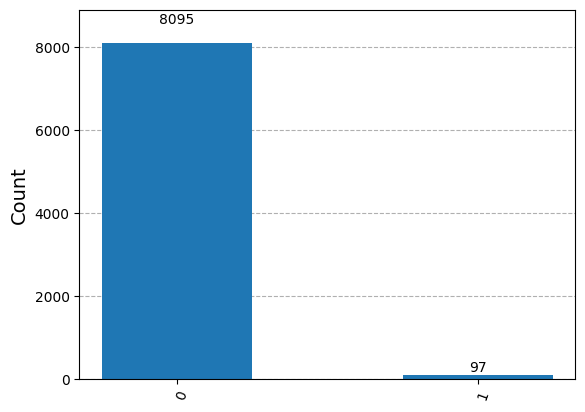

In [ ]:
plot_histogram(pub_result)